# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [118]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score
import plotly.express as px

In [119]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [120]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [121]:
df.shape #check the size

(41188, 21)

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [122]:
df.info() #look at the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [123]:
df.isnull().sum() #Checking for missing values

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

There aren't conventional NaN or null missing values

In [124]:
unknown_counts = {} # Check each column for 'unknown' values and store the results

for col in df.columns:
    count = (df[col] == 'unknown').sum() # Count occurrences where the cell equals the string 'unknown'
    if count > 0:
        unknown_counts[col] = (count)

print(unknown_counts)

{'job': np.int64(330), 'marital': np.int64(80), 'education': np.int64(1731), 'default': np.int64(8597), 'housing': np.int64(990), 'loan': np.int64(990)}


The 'default' column has high 'unknown' values (8597). Decided to treat 'unknown' as its own distinct category during One-Hot Encoding.

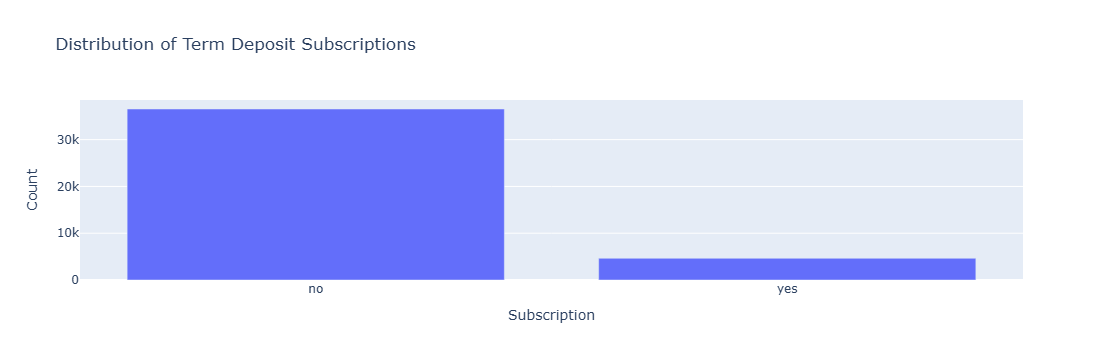

In [125]:
target_counts = df['y'].value_counts().reset_index()
target_counts.columns = ['Subscription', 'Count']

fig = px.bar(
    target_counts,
    x='Subscription',
    y='Count',
    title='Distribution of Term Deposit Subscriptions'
)

fig.show()

Categorical variables: job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

Numeric variables: age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

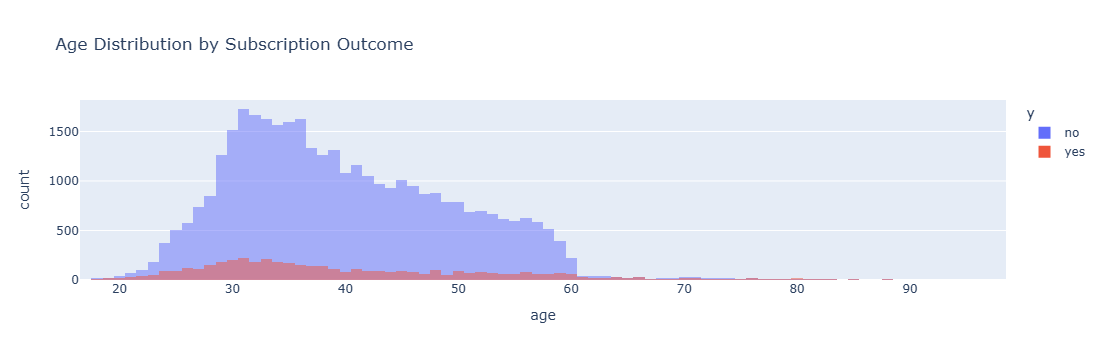

In [126]:
fig = px.histogram(
    df,
    x='age',
    color='y',
    barmode='overlay',
    title='Age Distribution by Subscription Outcome'
)

fig.show()

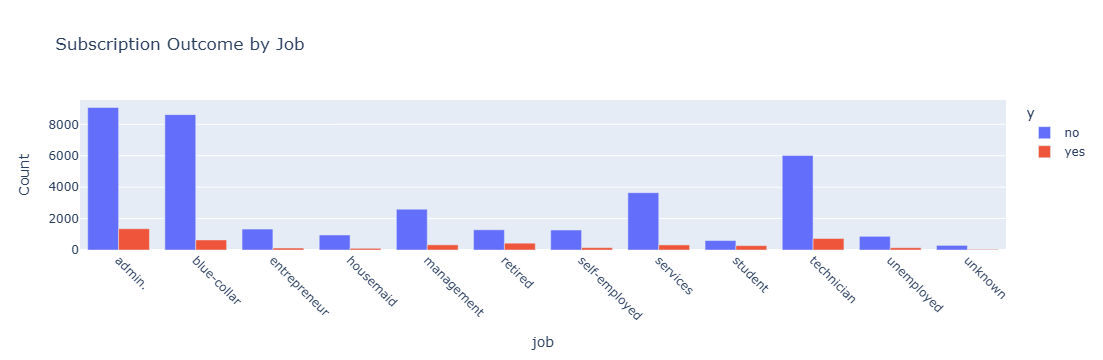

In [127]:
job_counts = df.groupby(['job', 'y']).size().reset_index(name='Count')

fig = px.bar(
    job_counts,
    x='job',
    y='Count',
    color='y',
    barmode='group',
    title='Subscription Outcome by Job'
)

fig.update_xaxes(tickangle=45)

fig.show()

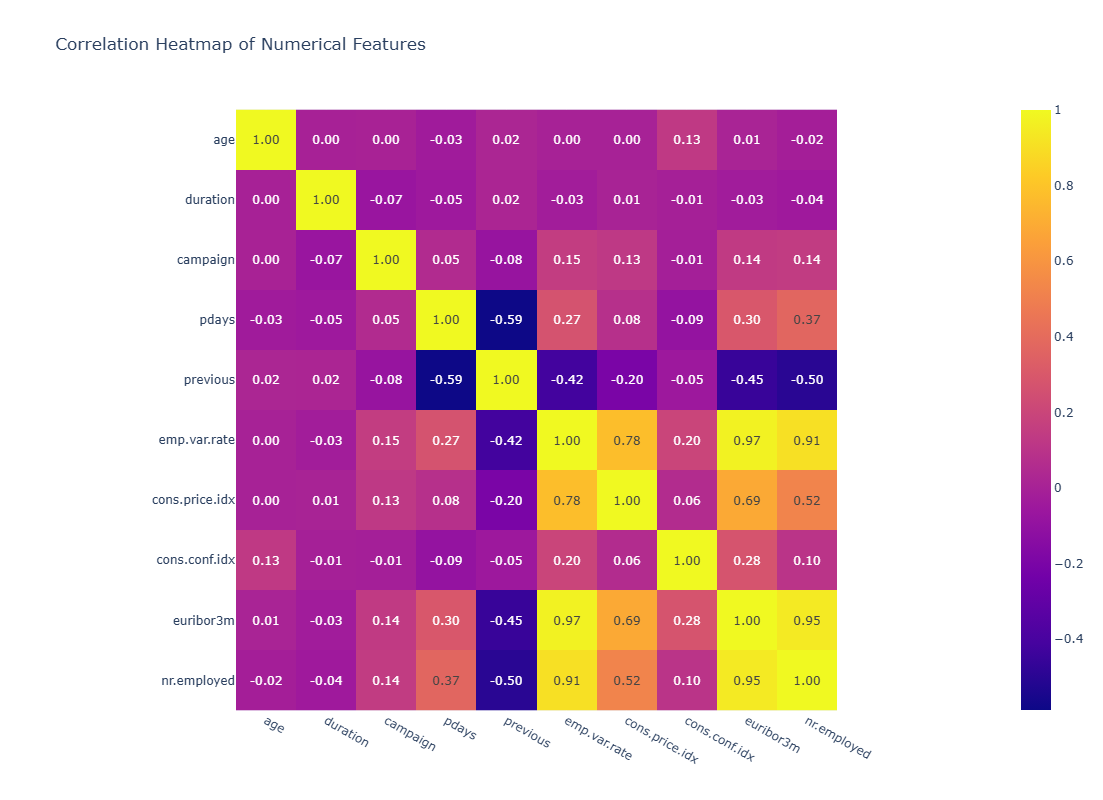

In [128]:
numeric_data = df.select_dtypes(include='number')

corr = numeric_data.corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    title='Correlation Heatmap of Numerical Features'
)

# increase the display size
fig.update_layout(
    width=800,
    height=800
)

fig.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The business objective is to predict whether a bank client will subscribe to a term deposit as a result of a marketing campaign. The goal is to identify customers more likely to subscribe so that the bank can focus its marketing efforts on those customers.
[Yes: Subscribe, 
No: Did not subscribe]

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [130]:
# select the seven bank features:

num_features = ['age']

cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']


X = df[num_features + cat_features].copy()
y = df['y'].copy()

In [131]:
X.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


In [132]:
y.value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Need to encode categorical variables: 'job', 'marital', 'education', 'default', 'housing', 'loan' using One-Hot Encoding and scaling 'age' as well.

In [134]:
col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False), cat_features)
    ]
)

X_train_encoded = col_transformer.fit_transform(X_train) # Fit on training data
X_test_encoded = col_transformer.transform(X_test)

In [135]:
X_train_encoded = pd.DataFrame(X_train_encoded)
X_train_encoded.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.863739,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.289722,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.651268,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.385843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.824956,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [136]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(32950, 28)
(8238, 28)


In [137]:
a = y_train.value_counts(normalize=True) #percentage of 'yes' same in both datasets
b = y_test.value_counts(normalize=True)
print(a)
print(b)

y
no     0.887344
yes    0.112656
Name: proportion, dtype: float64
y
no     0.887351
yes    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In a binary classification problem with high class imbalance, the baseline will be to predict the Most Frequent Classifier accuracy 'No' which is 88.7%

In [138]:
baseline_accuracy = df['y'].value_counts().max()/df['y'].count()
baseline_accuracy

np.float64(0.8873458288821987)

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [139]:
lr_model = LogisticRegression(class_weight='balanced') #logistic regression model

lr_model.fit(X_train_encoded, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Problem 9: Score the Model

What is the accuracy of your model?

In [140]:
train_acc = lr_model.score(X_train_encoded, y_train) #accuracy scores of the logistic regression model
test_acc = lr_model.score(X_test_encoded, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

Training Accuracy: 0.5904
Test Accuracy:     0.5845


Training accuracy (59.04%) and Test accuracy (58.45%) are nearly identical which means that the model is not overfitting. In highly imbalanced datasets, overall accuracy is a misleading metric. A model with 58% accuracy that actually detects "Yes" cases is more useful in the real world than an 88.7% accurate baseline that completely ignores them.

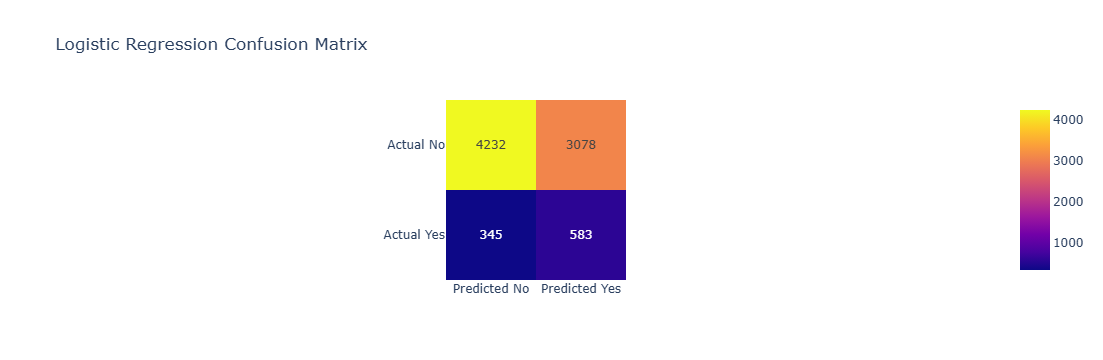

In [141]:
y_pred_lr = lr_model.predict(X_test_encoded)
cm = confusion_matrix(y_test, y_pred_lr)

fig = px.imshow(
    cm,
    text_auto=True,
    x=['Predicted No', 'Predicted Yes'],
    y=['Actual No', 'Actual Yes'],
    title='Logistic Regression Confusion Matrix'
)

fig.show()


In [142]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          no       0.92      0.58      0.71      7310
         yes       0.16      0.63      0.25       928

    accuracy                           0.58      8238
   macro avg       0.54      0.60      0.48      8238
weighted avg       0.84      0.58      0.66      8238



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [143]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=None),
    'SVM': SVC(C=1.0,kernel='rbf',gamma='scale')
}


results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_encoded, y_train)
    fit_time = time.time() - start_time
    
    train_acc = model.score(X_train_encoded, y_train)
    test_acc = model.score(X_test_encoded, y_test)
    
    results.append({
        'Model': name,
        'Train Time': round(fit_time, 2),
        'Train Accuracy': round(train_acc, 2),
        'Test Accuracy': round(test_acc, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Train Time  Train Accuracy  Test Accuracy
0  Logistic Regression        0.18            0.59           0.58
1                  KNN        0.04            0.89           0.88
2        Decision Tree        0.20            0.92           0.86
3                  SVM       82.06            0.89           0.89


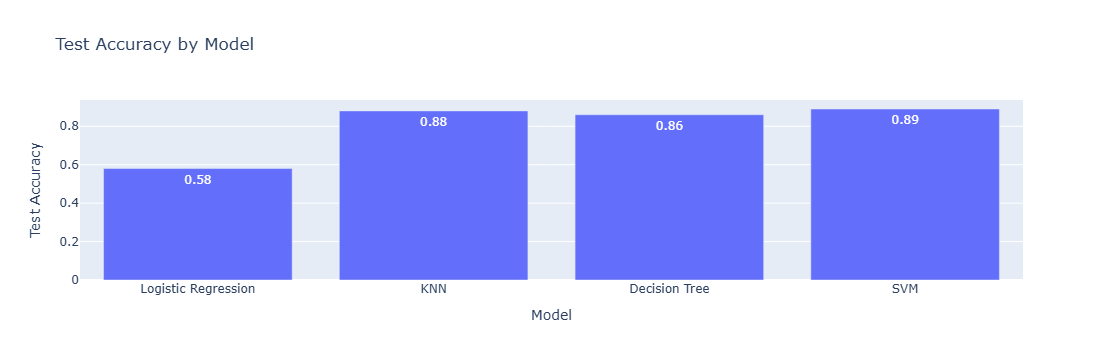

In [144]:
fig = px.bar(
    results_df,
    x='Model',
    y='Test Accuracy',
    title='Test Accuracy by Model',
    text_auto='.2f'
)

fig.show()

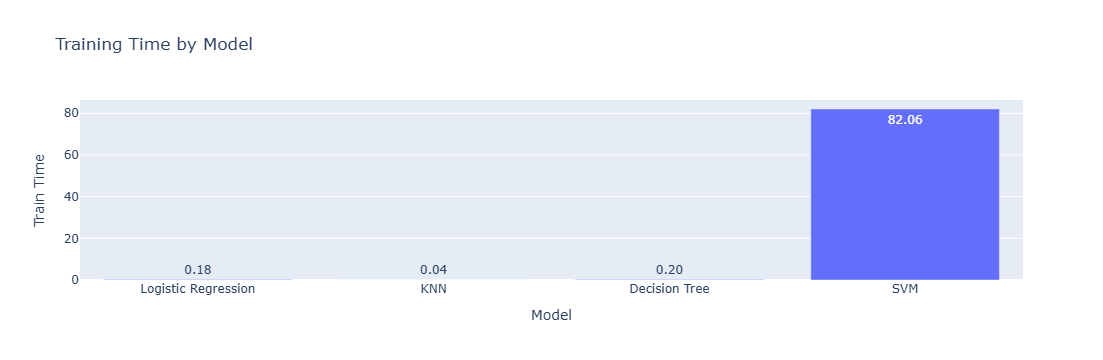

In [145]:
fig = px.bar(
    results_df,
    x='Model',
    y='Train Time',
    title='Training Time by Model',
    text_auto='.2f'
)

fig.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [146]:
# Logistic Regression Parameters
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid=lr_params,
    cv=5
)

lr_grid.fit(X_train_encoded, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)
print("Best Logistic Regression score:")
print(lr_grid.best_score_)

Best Logistic Regression parameters:
{'C': 10}
Best Logistic Regression score:
0.5913201820940819


In [147]:
#KNN Parameters
knn_params = {
    'n_neighbors': [3, 5, 10, 15, 20, 50, 75, 80]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5
)

knn_grid.fit(X_train_encoded, y_train)

print("Best KNN parameters:")
print(knn_grid.best_params_)
print("Best KNN score:")
print(knn_grid.best_score_)

Best KNN parameters:
{'n_neighbors': 75}
Best KNN score:
0.8873444613050075


In [148]:
#Decision Tree Parameters
dt_params = {
    'max_depth': [3, 5, 10, 15, 20, None],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5
)

dt_grid.fit(X_train_encoded, y_train)

print("Best Decision Tree parameters:")
print(dt_grid.best_params_)
print("Best Decision Tree score:")
print(dt_grid.best_score_)

Best Decision Tree parameters:
{'max_depth': 3}
Best Decision Tree score:
0.8873444613050075


In [149]:
#SVM Parameters
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale']
}

svm_grid = GridSearchCV(
    SVC(),
    param_grid=svm_params,
    cv = 3,
    n_jobs=-1
)

svm_grid.fit(X_train_encoded, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)
print("Best SVM score:")
print(svm_grid.best_score_)

Best SVM parameters:
{'C': 1, 'gamma': 'scale'}
Best SVM score:
0.8874962126132958


In [150]:
#Compare models with best parameters
best_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'SVM': svm_grid.best_estimator_
}

best_results = []

for name, model in best_models.items():
    
    y_pred = model.predict(X_test_encoded)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    best_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1
    })

best_results_df = pd.DataFrame(best_results)

best_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,Decision Tree,0.887351,0.494655
1,KNN,0.887230,0.490686
0,Logistic Regression,0.583880,0.482099
3,SVM,0.886502,0.478299


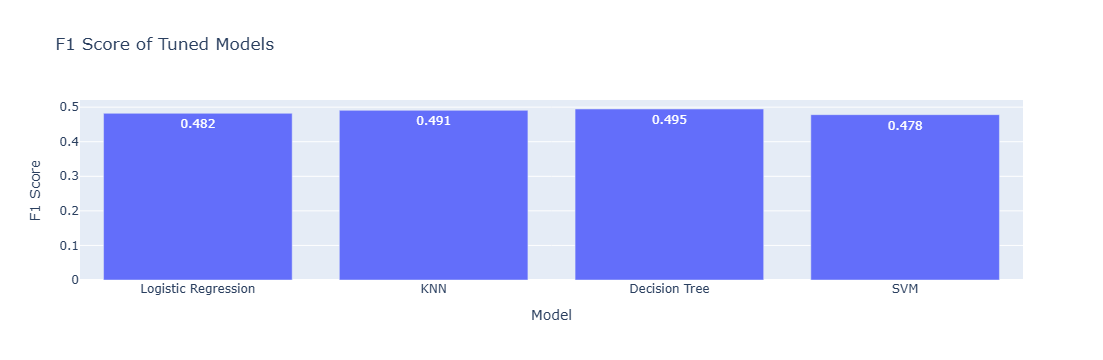

In [151]:
fig = px.bar(
    best_results_df,
    x='Model',
    y='F1 Score',
    title='F1 Score of Tuned Models',
    text_auto='.3f'
)

fig.show()

F1 gives a better idea of how well the model identifies the less-common class 'Yes' so F1 score is a better choice to explore.

In [152]:
best_results_f1 = []

for name, model in best_models.items():
    
    y_pred = model.predict(X_test_encoded)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label='yes')
    
    best_results_f1.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score (yes)': f1
    })

best_results_f1_df = pd.DataFrame(best_results_f1)

best_results_f1_df.sort_values(
    by='F1 Score (yes)',
    ascending=False
)

,Model,Accuracy,F1 Score (yes)
0,Logistic Regression,0.583880,0.252508
2,Decision Tree,0.887351,0.049180
1,KNN,0.887230,0.041280
3,SVM,0.886502,0.016824


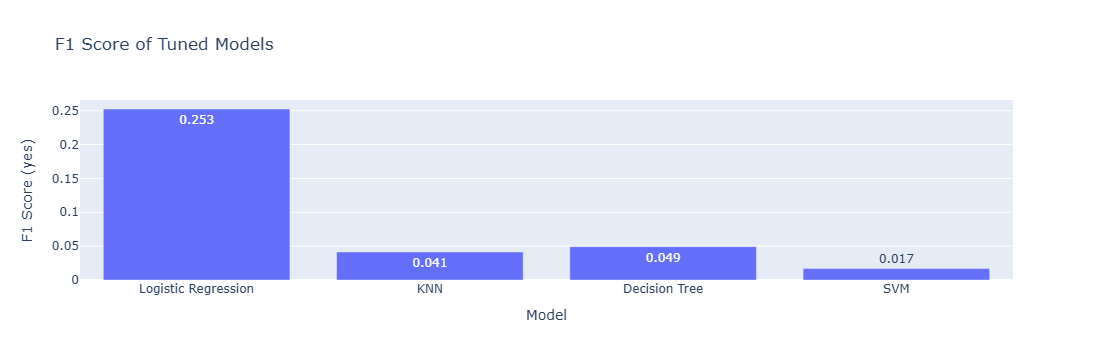

In [153]:
fig = px.bar(
    best_results_f1_df,
    x='Model',
    y='F1 Score (yes)',
    title='F1 Score of Tuned Models',
    text_auto='.3f'
)

fig.show()

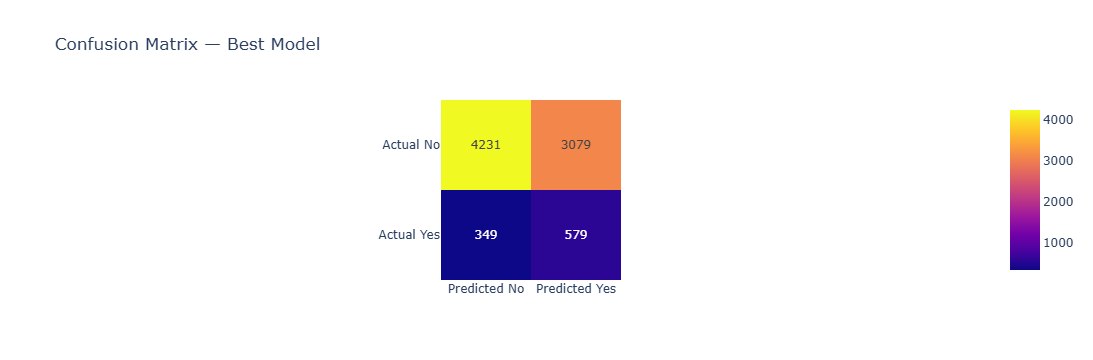

In [154]:
best_model = lr_grid.best_estimator_

y_pred_best = best_model.predict(X_test_encoded)

cm = confusion_matrix(y_test, y_pred_best)

fig = px.imshow(
    cm,
    text_auto=True,
    x=['Predicted No', 'Predicted Yes'],
    y=['Actual No', 'Actual Yes'],
    title='Confusion Matrix — Best Model'
)

fig.show()

##### Questions